# 05 — From a complete PDF to an evidence-grounded answer

**Measured end-to-end evaluation, followed by a targeted context experiment.** The system retrieves pages from a complete PDF, answers with the selected 9B vision-language model, validates its citations, and scores the actual response. Every one of the 16 training questions remains in the denominator.

The first pass exposed a gap that separate component scores could not predict. A second experiment asks whether rereading the model's own cited pages reduces distracting context. The routing rule uses no reference answer or gold evidence; both passes and every failure remain visible.

**Read the saved outputs without an account or GPU.** Run All with the defaults reads verified public results. These are development measurements on five previously examined PDFs, with a pinned local implementation of the published metric.

In [1]:
import json
from pathlib import Path

from IPython.display import HTML, SVG, display

from lava.evaluation.reporting import load_report
from lava.evaluation.system import load_summary
from lava.evaluation.system_reporting import verified_system_figure
from lava.evaluation.walkthrough import TABLE_STYLE, render_table
from lava.notebook_support import find_repo_root
from lava.readers.refinement import load_refinement
from lava.readers.runtime_logging import RuntimeEventLogger
from lava.retrieval.pipeline import load_public_report
from lava.retrieval.reporting import recall_chart

ROOT = find_repo_root(Path.cwd())
logger = RuntimeEventLogger("notebook.system")
with logger.stage("01_verify_evidence", heartbeat_seconds=15):
    readers = load_report(ROOT)
    baseline = next(
        row for row in readers["current_models"] if row["model_key"] == "qwen35_9b_fused_direct"
    )
    assert baseline["complete"] and baseline["semantic_summary"]["contract_current"]
    oracle = baseline["semantic_summary"]["metrics"]
    retrieval = load_public_report(ROOT)
    result = load_summary(ROOT)
    refined = load_refinement(ROOT)
    assert result is not None and refined is not None, (
        "The completed release requires both measured passes"
    )
    status = "First pass and citation-guided reread scored"
    display(
        HTML(
            TABLE_STYLE
            + render_table(
                [
                    {"Evidence": "Current end-to-end status", "Observation": status},
                    {
                        "Evidence": "Oracle baseline",
                        "Observation": f"{oracle['question_micro']['overall']:.2%} local LAVA; correct pages supplied",
                    },
                    {
                        "Evidence": "Labeled pilot",
                        "Observation": "16 previously examined questions / 5 PDFs / 15 Japanese + 1 Vietnamese",
                    },
                    {
                        "Evidence": "Claim boundary",
                        "Observation": "Training diagnostic; no hidden-test, organizer-server or state-of-the-art claim",
                    },
                ],
                caption="Verified evaluation scope",
            )
        )
    )

{"component": "notebook.system", "elapsed_seconds": 0.0, "event": "01_verify_evidence.started", "level": "INFO", "stage_elapsed_seconds": 0.0, "timestamp_utc": "2026-09-10T05:21:37.908+00:00"}


Evidence,Observation
Current end-to-end status,First pass and citation-guided reread scored
Oracle baseline,87.02% local LAVA; correct pages supplied
Labeled pilot,16 previously examined questions / 5 PDFs / 15 Japanese + 1 Vietnamese
Claim boundary,"Training diagnostic; no hidden-test, organizer-server or state-of-the-art claim"


{"component": "notebook.system", "elapsed_seconds": 0.369, "event": "01_verify_evidence.completed", "level": "INFO", "stage_elapsed_seconds": 0.369, "timestamp_utc": "2026-09-10T05:21:38.277+00:00"}


## Reproduce the measured workflow

The controls below are off by default and do not allocate a GPU. The completed first pass and its answer checkpoints are reusable. The fixed refinement experiment is operated with `make refine-preview`, `make refine-evaluate`, or the explicitly charge-gated `make refine-finish CHARGES=YES`; it rereads the saved first-pass citations.

The operator guide records the exact contracts and successful jobs. A new paid attempt requires an explicit attempt number and retry acknowledgement. The configured runtime ceiling is 1,800 seconds per attempt. Runtime and estimate guards are per attempt; existing Studio, storage and logs are separate.

In [2]:
from lava.notebook_operations import download_link, run_operation

RUN_PILOT = False
RUN_TEST_INFERENCE = False
EXPORT_SAVED_TEST = False
ACKNOWLEDGE_AWS_CHARGES = "NO"
PILOT_ATTEMPT = 1
TEST_ATTEMPT = 1
ALLOW_PAID_RETRY = False
PILOT_TRAINING_ESTIMATE_LIMIT_USD = 5.0
TEST_TRAINING_ESTIMATE_LIMIT_USD = 15.0

pilot_action = run_operation(
    ROOT,
    "pilot",
    enabled=RUN_PILOT,
    acknowledge_charges=ACKNOWLEDGE_AWS_CHARGES,
    attempt=PILOT_ATTEMPT,
    retry=ALLOW_PAID_RETRY,
    maximum_training_usd=PILOT_TRAINING_ESTIMATE_LIMIT_USD,
)
result = load_summary(ROOT)
display(HTML(render_table([pilot_action], caption="Your pilot execution control")))

{"cloud_access": false, "component": "notebook.operation", "elapsed_seconds": 0.0, "event": "notebook.operation.disabled", "level": "INFO", "operation": "pilot", "timestamp_utc": "2026-09-10T05:21:38.284+00:00"}


operation,status,uploaded_to_kaggle
pilot,disabled,False


## 2. Design useful inputs, not more features indiscriminately

For this document-AI task, feature engineering means **preserving the information the answer depends on**. Native text captures searchable words and numbers; page images retain tables, charts, and spatial relationships; explicit physical page numbers support auditable citations. More context can also introduce distractors and consume memory.

The frozen retrieval representation uses Unicode NFKC normalization, words, and character bigrams/trigrams. This lets Japanese match without whitespace tokenization while retaining Vietnamese diacritics. Frequencies and page-length normalization are computed within the queried PDF. Gold answers and gold page labels never enter the reader request.

The five-page budget was fixed for this final pilot **after examining the earlier retrieval diagnostics**; it is a development choice, not a held-out selection. Ten pages retrieved all known evidence but have not been demonstrated to improve answer quality or latency. We do not equate retrieval recall with answer accuracy.

In [3]:
with logger.stage("02_inspect_input_tradeoff", heartbeat_seconds=15):
    display(HTML(recall_chart(retrieval, "all_evidence_at_k")))
    display(
        HTML(
            render_table(
                [
                    {
                        "Input decision": "PDF text + rendered image",
                        "Reason": "Lexical matching plus visual tables/layout; no destructive text-only assumption",
                    },
                    {
                        "Input decision": "Five ranked pages, shown in physical order",
                        "Reason": "Bounded context; stable page identities instead of renumbered citations",
                    },
                    {
                        "Input decision": "Pinned source and model hashes",
                        "Reason": "Detect changed inputs; reuse only compatible answers",
                    },
                    {
                        "Input decision": "Labels separated from ReaderInput",
                        "Reason": "Reference answers and pages become visible only in the evaluator",
                    },
                ],
                caption="Information-preserving input design",
            )
        )
    )

{"component": "notebook.system", "elapsed_seconds": 0.384, "event": "02_inspect_input_tradeoff.started", "level": "INFO", "stage_elapsed_seconds": 0.0, "timestamp_utc": "2026-09-10T05:21:38.291+00:00"}


Input decision,Reason
PDF text + rendered image,Lexical matching plus visual tables/layout; no destructive text-only assumption
"Five ranked pages, shown in physical order",Bounded context; stable page identities instead of renumbered citations
Pinned source and model hashes,Detect changed inputs; reuse only compatible answers
Labels separated from ReaderInput,Reference answers and pages become visible only in the evaluator


{"component": "notebook.system", "elapsed_seconds": 0.387, "event": "02_inspect_input_tradeoff.completed", "level": "INFO", "stage_elapsed_seconds": 0.003, "timestamp_utc": "2026-09-10T05:21:38.295+00:00"}


## 3. Follow the actual execution path

Frozen source versions → reuse full-PDF text extraction → reuse label-blind BM25 rankings → render only selected unique pages → construct label-free `ReaderInput` → invoke the same pinned 9B reader → independently parse the exact generation → persist and read back each answer → evaluate with the unchanged semantic judge.

The original oracle experiment retains its strict gold-page-alignment contract. The new input type has no reference answer or gold evidence fields. Output citations must be members of the **supplied physical page set**, not the reference set. Invalid generations remain failures in the denominator.

A successful AWS job status is necessary but insufficient: complete question coverage, checksums, re-parsed outputs, judge controls, and public report integrity must also pass.

In [4]:
with logger.stage("03_inspect_frozen_execution", heartbeat_seconds=15):
    config = json.loads((ROOT / "configs/system_evaluation.json").read_text())
    display(
        HTML(
            render_table(
                [
                    {
                        "Contract": "Reader",
                        "Value": "Qwen3.5-9B / bfloat16 / direct deterministic decoding",
                    },
                    {"Contract": "Page budget", "Value": config["page_budget"]},
                    {
                        "Contract": "GPU attempt",
                        "Value": "One ml.g6e.8xlarge (one L40S GPU); 1,800-second runtime cap",
                    },
                    {
                        "Contract": "Resume",
                        "Value": "Reattach to a deterministic job name; skip verified answer checkpoints",
                    },
                    {
                        "Contract": "New paid retry",
                        "Value": "Separate explicit approval; never automatic",
                    },
                ],
                caption="Frozen inference and recovery contract",
            )
        )
    )

{"component": "notebook.system", "elapsed_seconds": 0.391, "event": "03_inspect_frozen_execution.started", "level": "INFO", "stage_elapsed_seconds": 0.0, "timestamp_utc": "2026-09-10T05:21:38.299+00:00"}


Contract,Value
Reader,Qwen3.5-9B / bfloat16 / direct deterministic decoding
Page budget,5
GPU attempt,"One ml.g6e.8xlarge (one L40S GPU); 1,800-second runtime cap"
Resume,Reattach to a deterministic job name; skip verified answer checkpoints
New paid retry,Separate explicit approval; never automatic


{"component": "notebook.system", "elapsed_seconds": 0.393, "event": "03_inspect_frozen_execution.completed", "level": "INFO", "stage_elapsed_seconds": 0.002, "timestamp_utc": "2026-09-10T05:21:38.301+00:00"}


## 4. Compare the official-formula components

The published LAVA formula averages semantic answer credit and evidence-page F1 per question. Unordered list answers use optimal semantic matching; ordered lists use semantic longest-common-subsequence credit. Our pinned local Gemma judge implements this evaluation structure, but the organizer's exact prompt/runtime is not published, so these are **local published-formula scores**, not official leaderboard scores.

The comparison below uses actual predicted evidence pages. Supplying the reference pages during scoring would incorrectly inflate the complete-system score. The oracle-to-retrieved difference includes missed evidence, distractor pages, and context-volume changes; it is not a pure causal estimate of retrieval alone.

{"component": "notebook.system", "elapsed_seconds": 0.398, "event": "04_compare_quality.started", "level": "INFO", "stage_elapsed_seconds": 0.0, "timestamp_utc": "2026-09-10T05:21:38.305+00:00"}


Metric,Oracle pages,Retrieved first pass,Self-cited reread
Semantic answer credit,80.15%,48.90%,67.65%
Evidence-page F1,93.90%,86.25%,88.33%
Local LAVA,87.02%,67.57%,77.99%


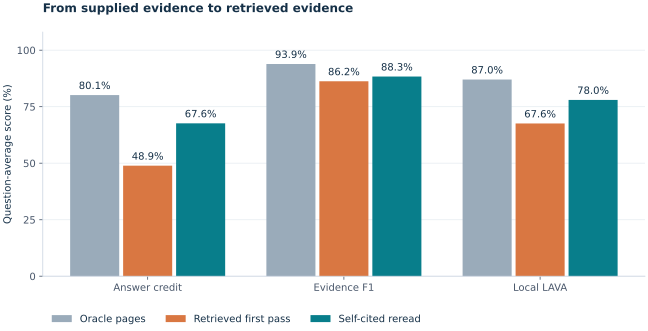

Weighting,Oracle,First pass,Reread
Question average,87.02%,67.57%,77.99%
Equal-document average,84.68%,67.00%,76.16%


{"component": "notebook.system", "elapsed_seconds": 0.407, "event": "04_compare_quality.completed", "level": "INFO", "stage_elapsed_seconds": 0.009, "timestamp_utc": "2026-09-10T05:21:38.315+00:00"}


In [5]:
def percent(value):
    return "Not measured" if value is None else f"{value:.2%}"


with logger.stage("04_compare_quality", heartbeat_seconds=15):
    current = result["metrics"]["question_micro"]
    reread = refined["metrics"]["question_micro"]
    display(
        HTML(
            render_table(
                [
                    {
                        "Metric": label,
                        "Oracle pages": percent(oracle["question_micro"][key]),
                        "Retrieved first pass": percent(current[key]),
                        "Self-cited reread": percent(reread[key]),
                    }
                    for key, label in (
                        ("answer", "Semantic answer credit"),
                        ("grounding", "Evidence-page F1"),
                        ("overall", "Local LAVA"),
                    )
                ],
                caption="Same pinned 9B reader and semantic judge; three input conditions",
            )
        )
    )
    display(SVG(verified_system_figure(ROOT, "quality.svg")))
    display(
        HTML(
            render_table(
                [
                    {
                        "Weighting": label,
                        "Oracle": percent(oracle[key]["overall"]),
                        "First pass": percent(result["metrics"][key]["overall"]),
                        "Reread": percent(refined["metrics"][key]["overall"]),
                    }
                    for key, label in (
                        ("question_micro", "Question average"),
                        ("document_macro", "Equal-document average"),
                    )
                ],
                caption="Question and document weighting",
            )
        )
    )

## A targeted context experiment

The first pass scored 67.57% local LAVA despite 95.31% retrieval recall. Nine questions had incomplete or incorrect answers even though all required evidence pages were available. Several numeric outputs lost digits or changed values. That motivated a specific hypothesis: reducing irrelevant context may help the existing reader.

The second pass keeps only the first pass's valid cited pages, in physical order. An empty or invalid citation set retains the original pages. The final answer is always the second output; there is no question-by-question selection using answer labels. Across all 16 questions this reduces page presentations from **76 to 27**. It cannot recover evidence missed by the first pass and can preserve an incorrect citation choice.

This is a post-hoc development experiment. Its extra GPU time and all regressions must be considered alongside the measured gain.

The measured gain is **10.42 percentage points** (67.57% → 77.99%). Complete input-evidence coverage falls from 14/16 to 12/16, so the smaller page set has a real tradeoff. Three document scores improved and two tied; the exact two-sided sign-flip p-value is 0.25. These five clusters do not establish a generalizable improvement.

## 5. Diagnose the errors before proposing another model

Each question is assigned one diagnostic category in this order: invalid response; missing required evidence; incomplete/incorrect answer despite complete evidence; incomplete citation; full credit. These categories are operational triage, not proof of causation. A missing page and an answer error can coexist.

Report every PDF and keep the single Vietnamese question visible as a sample-size limitation, not a language benchmark. The document-level paired interval is exploratory: only five PDFs were available, and all were previously examined during development.

{"component": "notebook.system", "elapsed_seconds": 0.414, "event": "05_examine_failures.started", "level": "INFO", "stage_elapsed_seconds": 0.0, "timestamp_utc": "2026-09-10T05:21:38.322+00:00"}


Diagnostic,First pass,Reread
answer incomplete or incorrect,9,5
evidence citation incomplete,1,0
full credit,4,7
missing evidence,2,4


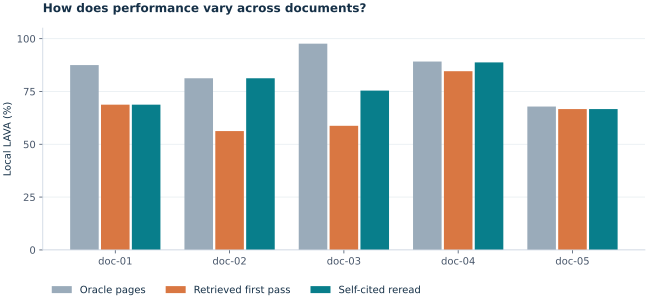

Question,PDF,First-pass LAVA,Reread LAVA,Reread diagnosis
q-01,doc-01,50.00%,50.00%,answer incomplete or incorrect
q-02,doc-02,100.00%,100.00%,full credit
q-03,doc-03,33.33%,33.33%,missing evidence
q-04,doc-04,100.00%,100.00%,full credit
q-05,doc-01,25.00%,25.00%,missing evidence
q-06,doc-02,25.00%,75.00%,missing evidence
q-07,doc-04,65.00%,65.00%,answer incomplete or incorrect
q-08,doc-01,100.00%,100.00%,full credit
q-09,doc-02,50.00%,100.00%,full credit
q-10,doc-03,92.86%,92.86%,answer incomplete or incorrect


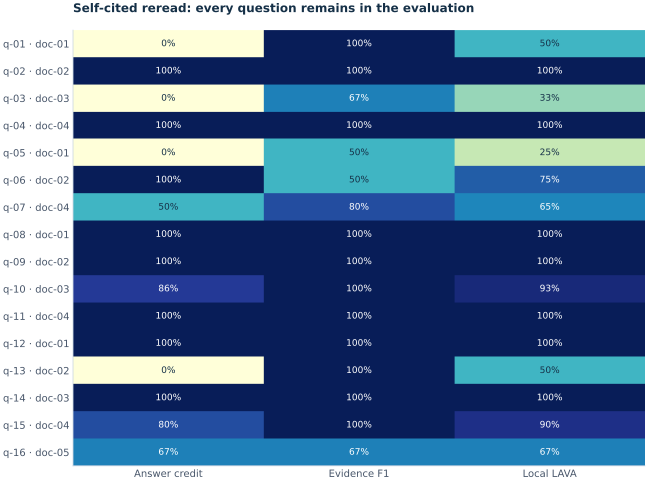

Improved / tied / regressed PDFs,Equal-document gain (pp),Exploratory sign-flip p-value,Exploratory bootstrap interval (pp)
3 / 2 / 0,9.170,0.250,"[0.83, 18.33]"


{"component": "notebook.system", "elapsed_seconds": 0.423, "event": "05_examine_failures.completed", "level": "INFO", "stage_elapsed_seconds": 0.009, "timestamp_utc": "2026-09-10T05:21:38.331+00:00"}


In [6]:
with logger.stage("05_examine_failures", heartbeat_seconds=15):
    categories = sorted(
        set(result["diagnostics"]["failure_counts"]) | set(refined["diagnostics"]["failure_counts"])
    )
    display(
        HTML(
            render_table(
                [
                    {
                        "Diagnostic": category.replace("_", " "),
                        "First pass": result["diagnostics"]["failure_counts"].get(category, 0),
                        "Reread": refined["diagnostics"]["failure_counts"].get(category, 0),
                    }
                    for category in categories
                ],
                caption="Every failure category is retained in both conditions",
            )
        )
    )
    display(SVG(verified_system_figure(ROOT, "documents.svg")))
    first_by_id = {row["question"]: row for row in result["per_question"]}
    display(
        HTML(
            render_table(
                [
                    {
                        "Question": row["question"],
                        "PDF": row["document"],
                        "First-pass LAVA": percent(first_by_id[row["question"]]["local_lava"]),
                        "Reread LAVA": percent(row["local_lava"]),
                        "Reread diagnosis": row["failure_category"].replace("_", " "),
                    }
                    for row in refined["per_question"]
                ],
                caption="Anonymous question diagnostics; scores come from actual generations",
            )
        )
    )
    display(SVG(verified_system_figure(ROOT, "questions.svg")))
    paired = refined["paired_document_comparison"]
    display(
        HTML(
            render_table(
                [
                    {
                        "Improved / tied / regressed PDFs": f"{paired['documents_improved']} / {paired['documents_tied']} / {paired['documents_regressed']}",
                        "Equal-document gain (pp)": round(100 * paired["mean_delta"], 2),
                        "Exploratory sign-flip p-value": paired[
                            "exact_two_sided_sign_flip_p_value"
                        ],
                        "Exploratory bootstrap interval (pp)": str(
                            [
                                round(100 * x, 2)
                                for x in paired["exploratory_cluster_bootstrap_95_interval"]
                            ]
                        ),
                    }
                ],
                caption="Paired reread versus first-pass diagnostics; five development PDFs",
            )
        )
    )

## 6. Measure execution and preserve successful work

Generation latency, reader latency, and AWS billable time measure different things. Reader timing includes preprocessing and, for the first uncached question, model loading; it excludes retrieval, provisioning, and durable writes. Recovered answers can span multiple GPU attempts. Do not call these measurements full competition-runtime compliance.

Each operator invocation records UTC timestamps, stage/total elapsed time, and heartbeats. Exact generations, answer checkpoints, judge decisions, completed reports, and successful notebook publications are durable in private S3. Analysis reruns verify existing outputs instead of paying for new inference.

In [7]:
with logger.stage("06_inspect_runtime_and_recovery", heartbeat_seconds=15):
    display(
        HTML(
            render_table(
                [
                    {
                        "Pass": name,
                        "Presented pages": sum(
                            row["input_pages"] for row in values["per_question"]
                        ),
                        "Mean generation (s)": round(
                            values["runtime"]["generation_mean_seconds"], 3
                        ),
                        "p95 generation (s)": round(values["runtime"]["generation_p95_seconds"], 3),
                        "Peak allocated (GiB)": round(values["runtime"]["peak_allocated_gib"], 2),
                    }
                    for name, values in (
                        ("Retrieved first pass", result),
                        ("Self-cited reread", refined),
                    )
                ],
                caption="Measured per-pass runtime; the two-pass system incurs both passes",
            )
        )
    )
    prices = {
        row["instance_type"]: row["usd_per_hour"]
        for row in json.loads((ROOT / "reports/aws/training_prices.json").read_text())["products"]
    }
    receipts = [
        json.loads((ROOT / "reports/system/attempt-3.json").read_text()),
        json.loads((ROOT / "reports/system/refinement/attempt-1.json").read_text()),
    ]
    display(
        HTML(
            render_table(
                [
                    {
                        "Pass": name,
                        "Instance": receipt["instance_type"],
                        "Billable seconds": receipt["billable_seconds"],
                        "Estimated training USD": round(
                            receipt["billable_seconds"] * prices[receipt["instance_type"]] / 3600, 4
                        ),
                        "Status": receipt["status"],
                    }
                    for name, receipt in zip(("First pass", "Reread"), receipts, strict=True)
                ],
                caption="Actual completed jobs at the dated public Training rate; excludes Studio and other charges",
            )
        )
    )
    total_compute = sum(
        receipt["billable_seconds"] * prices[receipt["instance_type"]] / 3600
        for receipt in receipts
    )
    display(
        HTML(
            render_table(
                [
                    {
                        "Both completed passes (Training USD)": round(total_compute, 4),
                        "Both passes, sum of mean generation (s)": round(
                            result["runtime"]["generation_mean_seconds"]
                            + refined["runtime"]["generation_mean_seconds"],
                            3,
                        ),
                        "Scope": "Includes both passes; excludes other attempts, Studio and other service charges",
                    }
                ],
                caption="Total work required by the measured two-pass pipeline",
            )
        )
    )

{"component": "notebook.system", "elapsed_seconds": 0.43, "event": "06_inspect_runtime_and_recovery.started", "level": "INFO", "stage_elapsed_seconds": 0.0, "timestamp_utc": "2026-09-10T05:21:38.338+00:00"}


Pass,Presented pages,Mean generation (s),p95 generation (s),Peak allocated (GiB)
Retrieved first pass,76,6.357,7.751,21.480
Self-cited reread,27,3.768,6.493,20.650


Pass,Instance,Billable seconds,Estimated training USD,Status
First pass,ml.g6e.8xlarge,409,0.643,Completed
Reread,ml.g6e.8xlarge,355,0.558,Completed


Both completed passes (Training USD),"Both passes, sum of mean generation (s)",Scope
1.201,10.126,"Includes both passes; excludes other attempts, Studio and other service charges"


{"component": "notebook.system", "elapsed_seconds": 0.434, "event": "06_inspect_runtime_and_recovery.completed", "level": "INFO", "stage_elapsed_seconds": 0.003, "timestamp_utc": "2026-09-10T05:21:38.341+00:00"}


## Generate and download your own submission

**You generate the file here; you decide when and whether to upload it.** This is not the 16-row training diagnostic and it never uses the sample template's placeholder answers. The code reads the pinned test inputs, retrieves evidence for all **624 questions across 200 PDFs**, runs the same pinned 9B reader, validates every ID and physical page number, writes a UTF-8 CSV in template order, and displays a local download link. No code in this workflow invokes a Kaggle upload API.

Set `RUN_TEST_INFERENCE = True` and explicitly acknowledge charges in the control cell above, then execute this section. Test inference is a **separate paid operation**: one GPU, a 7,200-second runtime limit, a $15 per-attempt estimate guard (not an account-wide cap), and no automatic paid retry. Actual full-test throughput and competition eligibility are not yet verified. Do not start it while the pilot GPU job is running.

After completed inference, set `RUN_TEST_INFERENCE = False` and `EXPORT_SAVED_TEST = True` to reconstruct the file from durable predictions without a new GPU job. A disconnect reuses the same attempt and compatible checkpoints; an interrupted uncommitted question may repeat. Invalid or abstained answers are retained for private review and block a misleading 'complete' export rather than becoming invented answers. The existing `prepare_submission.py --mode build` interface also validates predictions you have reviewed independently.

The file appears at `artifacts/submission/submission.csv`; its checksum and provenance are in `manifest.json`, and the immutable bundle remains in private S3. The notebook output contains only a link—not embedded questions, answers, or CSV bytes. In Studio, you can also find that file in the file browser, right-click it, and select **Download**. Manual upload/competition acceptance is your separate action.

Before publishing the notebook on GitHub, restore run controls to `False` and charges to `"NO"`; `make notebooks` publishes the safe, analysis-only view. Do not commit private files from `artifacts/`.

In [8]:
test_action = run_operation(
    ROOT,
    "test",
    enabled=RUN_TEST_INFERENCE,
    acknowledge_charges=ACKNOWLEDGE_AWS_CHARGES,
    attempt=TEST_ATTEMPT,
    retry=ALLOW_PAID_RETRY,
    maximum_training_usd=TEST_TRAINING_ESTIMATE_LIMIT_USD,
)
export_action = run_operation(ROOT, "export", enabled=EXPORT_SAVED_TEST)
display(HTML(render_table([test_action, export_action], caption="Your test and export controls")))
display(HTML(download_link(ROOT)))

{"cloud_access": false, "component": "notebook.operation", "elapsed_seconds": 0.0, "event": "notebook.operation.disabled", "level": "INFO", "operation": "test", "timestamp_utc": "2026-09-10T05:21:38.346+00:00"}


{"cloud_access": false, "component": "notebook.operation", "elapsed_seconds": 0.0, "event": "notebook.operation.disabled", "level": "INFO", "operation": "export", "timestamp_utc": "2026-09-10T05:21:38.347+00:00"}


operation,status,uploaded_to_kaggle
test,disabled,False
export,disabled,False


## 7. Close the experiment with an evidence-based decision

The release includes the complete retrieval-to-answer pipeline and a measured refinement, alongside the 4B/9B/27B oracle comparison, the 1,582-candidate lexical audit and the visual challenger. The second read uses the same model, prompt, image assets and judge; only the page subset changes.

The refinement was designed after inspecting first-pass development errors. Its result is useful engineering evidence, not an independent estimate of generalization. Both passes remain published, including regressions. The broader feature-research gate and the complete test submission remain open. Notebook 04 includes the document-feature ablations and their explicit limitations.

The concrete deliverable is a reproducible research system with measured behavior, durable artifacts, recovery tests, static and interactive analysis, and six executed notebooks. This completed research can be reviewed now, but it does not close the remaining project acceptance criteria.

In [9]:
with logger.stage("07_record_conclusion", heartbeat_seconds=15):
    conclusion = (
        f"First-pass local LAVA: {result['metrics']['question_micro']['overall']:.2%}; "
        f"self-cited reread: {refined['metrics']['question_micro']['overall']:.2%}; "
        f"change: {100 * refined['first_pass_delta']:+.2f} percentage points. "
        "The fixed second read uses model citations without gold-page selection. "
        "Keep both measured conditions and the five-document development limitation visible."
    )
    display(
        HTML(render_table([{"Conclusion": conclusion}], caption="Completed integrated evaluation"))
    )

{"component": "notebook.system", "elapsed_seconds": 0.445, "event": "07_record_conclusion.started", "level": "INFO", "stage_elapsed_seconds": 0.0, "timestamp_utc": "2026-09-10T05:21:38.352+00:00"}


Conclusion
First-pass local LAVA: 67.57%; self-cited reread: 77.99%; change: +10.42 percentage points. The fixed second read uses model citations without gold-page selection. Keep both measured conditions and the five-document development limitation visible.


{"component": "notebook.system", "elapsed_seconds": 0.447, "event": "07_record_conclusion.completed", "level": "INFO", "stage_elapsed_seconds": 0.002, "timestamp_utc": "2026-09-10T05:21:38.354+00:00"}


## 8. Separate saved test coverage from development accuracy

The targeted test recovery finished on September 10, 2026 UTC. It preserved 619
complete answers and recovered three more using fixed operator-selected page
routes and a geometric detail crop with the same pinned 9B reader. The routing
plan contained no candidate answers and used no hidden reference labels.

All new raw outputs were independently reparsed against the frozen questions,
PDF sources and routes. Two suspected question/PDF mismatches remain unresolved.
**622/624 is structural completeness, not answer accuracy or a Kaggle score.**
No complete CSV was exported or uploaded. Further GPU calls are not a substitute
for valid source evidence for those two questions.


In [10]:
with logger.stage("08_verify_test_recovery_status", heartbeat_seconds=15):
    recovery_path = ROOT / "reports/submission/targeted_recovery.json"
    recovery = json.loads(recovery_path.read_bytes())
    assert recovery["canonical_validation_passed"] is True
    assert recovery["total_complete_count"] == 622
    assert recovery["csv_exported"] is False and recovery["uploaded_to_kaggle"] is False
    display(
        HTML(
            render_table(
                [
                    {"Stage": "First pass", "Count": 550},
                    {"Stage": "OCR recovery added", "Count": 69},
                    {"Stage": "Targeted recovery added", "Count": 3},
                    {
                        "Stage": "Total preserved",
                        "Count": recovery["total_complete_count"],
                    },
                    {
                        "Stage": "Source blockers remaining",
                        "Count": recovery["unresolved_count"],
                    },
                ],
                caption="Actual saved test coverage; no hidden-label score",
            )
        )
    )
    print("Kaggle submission: blocked pending source clarification and complete CSV validation.")
logger.emit("system.walkthrough.completed", measured=True, question_count=16, measured_passes=2)


{"component": "notebook.system", "elapsed_seconds": 0.451, "event": "08_verify_test_recovery_status.started", "level": "INFO", "stage_elapsed_seconds": 0.0, "timestamp_utc": "2026-09-10T05:21:38.359+00:00"}


Stage,Count
First pass,550
OCR recovery added,69
Targeted recovery added,3
Total preserved,622
Source blockers remaining,2


Kaggle submission: blocked pending source clarification and complete CSV validation.
{"component": "notebook.system", "elapsed_seconds": 0.453, "event": "08_verify_test_recovery_status.completed", "level": "INFO", "stage_elapsed_seconds": 0.002, "timestamp_utc": "2026-09-10T05:21:38.361+00:00"}


{"component": "notebook.system", "elapsed_seconds": 0.454, "event": "system.walkthrough.completed", "level": "INFO", "measured": true, "measured_passes": 2, "question_count": 16, "timestamp_utc": "2026-09-10T05:21:38.362+00:00"}
